In [246]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mayedaislam/heart-failure-prediction/heart_failure_clinical_records_dataset-selected-columns.csv


In [247]:
import pandas as pd

path  = "/kaggle/input/datasets/mayedaislam/heart-failure-prediction/heart_failure_clinical_records_dataset-selected-columns.csv"
df = pd.read_csv(path) 
df.head(10)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
0,75.0,0,582,0,20,1,265000.00,1.9,130,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0
5,90.0,1,47,0,40,1,204000.00,2.1,132,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0
9,80.0,1,123,0,35,1,388000.00,9.4,133,1


In [248]:
df.tail(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
289,90.0,1,337,0,38,0,390000.0,0.9,144,0
290,45.0,0,615,1,55,0,222000.0,0.8,141,0
291,60.0,0,320,0,35,0,133000.0,1.4,139,1
292,52.0,0,190,1,38,0,382000.0,1.0,140,1
293,63.0,1,103,1,35,0,179000.0,0.9,136,1
294,62.0,0,61,1,38,1,155000.0,1.1,143,1
295,55.0,0,1820,0,38,0,270000.0,1.2,139,0
296,45.0,0,2060,1,60,0,742000.0,0.8,138,0
297,45.0,0,2413,0,38,0,140000.0,1.4,140,1
298,50.0,0,196,0,45,0,395000.0,1.6,136,1


In [249]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
dtype: int64

In [250]:
print("Before ", df.shape[0])
df = df.drop_duplicates()
print("After ", df.shape[0])

Before  299
After  299


In [251]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_scale = [
    'age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 
    'ejection_fraction', 'high_blood_pressure', 'platelets', 
    'serum_creatinine', 'serum_sodium', 'sex'
]

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print(df.head())

        age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  0.636364      0.0                  0.071319       0.0           0.090909   
1  0.272727      0.0                  1.000000       0.0           0.363636   
2  0.454545      0.0                  0.015693       0.0           0.090909   
3  0.181818      1.0                  0.011227       0.0           0.090909   
4  0.454545      1.0                  0.017479       1.0           0.090909   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  
0                  1.0   0.290823          0.157303      0.485714  1.0  
1                  0.0   0.288833          0.067416      0.657143  1.0  
2                  0.0   0.165960          0.089888      0.457143  1.0  
3                  0.0   0.224148          0.157303      0.685714  1.0  
4                  0.0   0.365984          0.247191      0.085714  0.0  


In [252]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Define X by dropping the 'sex' column (X now has the remaining 9 columns)
X = df.drop("sex", axis=1)

# 2. Define y by choosing ONLY the 'sex' column as target
y = df["sex"]

# 3. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# 4. Initialize the Logistic Regression model
model = DecisionTreeClassifier()

# 5. Train the model using the training data
model.fit(X_train, y_train)

# 6. Make predictions on the test dataset
pred = model.predict(X_test)

# 7. Calculate and print the final accuracy score
accuracy = accuracy_score(y_test, pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.45


In [253]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Define X by dropping the 'sex' column (X now has the remaining 9 columns)
X = df.drop("sex", axis=1)

# 2. Define y by choosing ONLY the 'sex' column as target
y = df["sex"]

# 3. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# 4. Initialize the Logistic Regression model
model = RandomForestClassifier()

# 5. Train the model using the training data
model.fit(X_train, y_train)

# 6. Make predictions on the test dataset
pred = model.predict(X_test)

# 7. Calculate and print the final accuracy score
accuracy = accuracy_score(y_test, pred)
print("RandomForestClassifier Model Accuracy:", accuracy)

RandomForestClassifier Model Accuracy: 0.5666666666666667


In [254]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Define X by dropping the 'sex' column (X now has the remaining 9 columns)
X = df.drop("sex", axis=1)

# 2. Define y by choosing ONLY the 'sex' column as target
y = df["sex"]

# 3. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# 4. Initialize the Logistic Regression model
model = KNeighborsClassifier()

# 5. Train the model using the training data
model.fit(X_train, y_train)

# 6. Make predictions on the test dataset
pred = model.predict(X_test)

# 7. Calculate and print the final accuracy score
accuracy = accuracy_score(y_test, pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.6333333333333333


In [255]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Define X by dropping the 'sex' column (X now has the remaining 9 columns)
X = df.drop("sex", axis=1)

# 2. Define y by choosing ONLY the 'sex' column as target
y = df["sex"]

# 3. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# 4. Initialize the Logistic Regression model
model = GaussianNB()

# 5. Train the model using the training data
model.fit(X_train, y_train)

# 6. Make predictions on the test dataset
pred = model.predict(X_test)

# 7. Calculate and print the final accuracy score
accuracy = accuracy_score(y_test, pred)
print("Naive Byaes Model Accuracy:", accuracy)

Naive Byaes Model Accuracy: 0.6333333333333333


In [256]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Define X by dropping the 'sex' column (X now has the remaining 9 columns)
X = df.drop("sex", axis=1)

# 2. Define y by choosing ONLY the 'sex' column as target
y = df["sex"]

# 3. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# 4. Initialize the Logistic Regression model
model = LogisticRegression()

# 5. Train the model using the training data
model.fit(X_train, y_train)

# 6. Make predictions on the test dataset
pred = model.predict(X_test)

# 7. Calculate and print the final accuracy score
accuracy = accuracy_score(y_test, pred)
print("Logistic  regression Model Accuracy:", accuracy)

Logistic  regression Model Accuracy: 0.6666666666666666


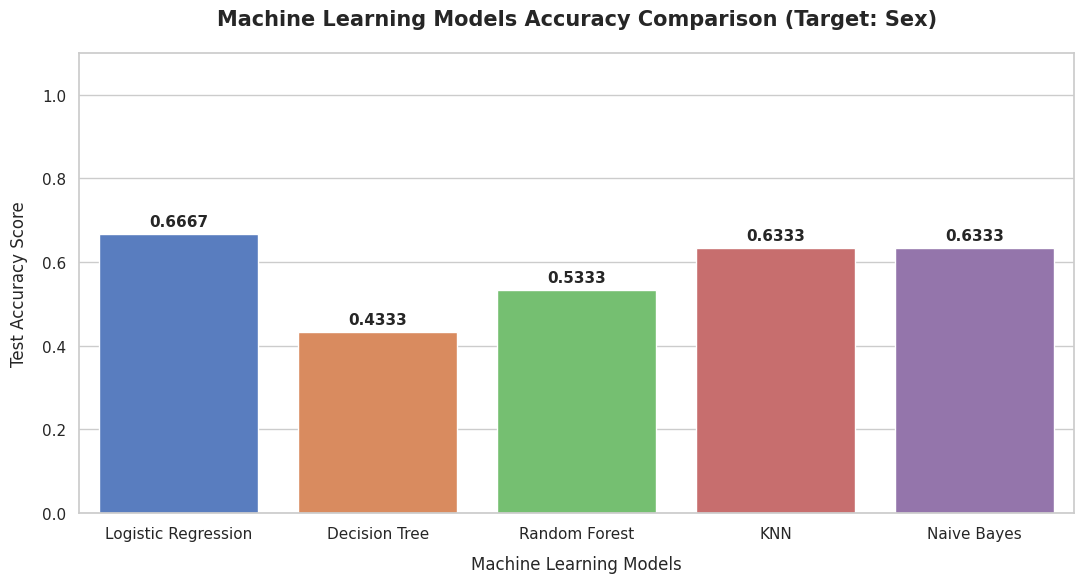

In [257]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Prepare X and y (Target: sex) using your 10 columns
X = df.drop("sex", axis=1)
y = df["sex"]

# 2. Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize your exact 5 models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# 4. Train models and collect accuracy scores dynamically
model_accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)          # Train the model
    pred = model.predict(X_test)         # Make predictions
    acc = accuracy_score(y_test, pred)   # Calculate accuracy
    model_accuracies[name] = acc         # Save to dictionary

# 5. Set up the plotting environment aesthetics
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# 6. FIXED: Assign x to hue, set legend=False, and match palette length (5)
colors = sns.color_palette("muted", n_colors=5)
ax = sns.barplot(
    x=list(model_accuracies.keys()), 
    y=list(model_accuracies.values()), 
    hue=list(model_accuracies.keys()),
    palette=colors,
    legend=False
)

# 7. Add exact accuracy numbers on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.4f}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        xytext=(0, 9), 
        textcoords='offset points',
        fontsize=11,
        weight='bold'
    )

# 8. Label the chart elements cleanly
plt.title('Machine Learning Models Accuracy Comparison (Target: Sex)', fontsize=15, pad=20, weight='bold')
plt.xlabel('Machine Learning Models', fontsize=12, labelpad=10)
plt.ylabel('Test Accuracy Score', fontsize=12, labelpad=10)
plt.ylim(0, 1.1)

# 9. Render the final graph on your screen
plt.tight_layout()
plt.show()

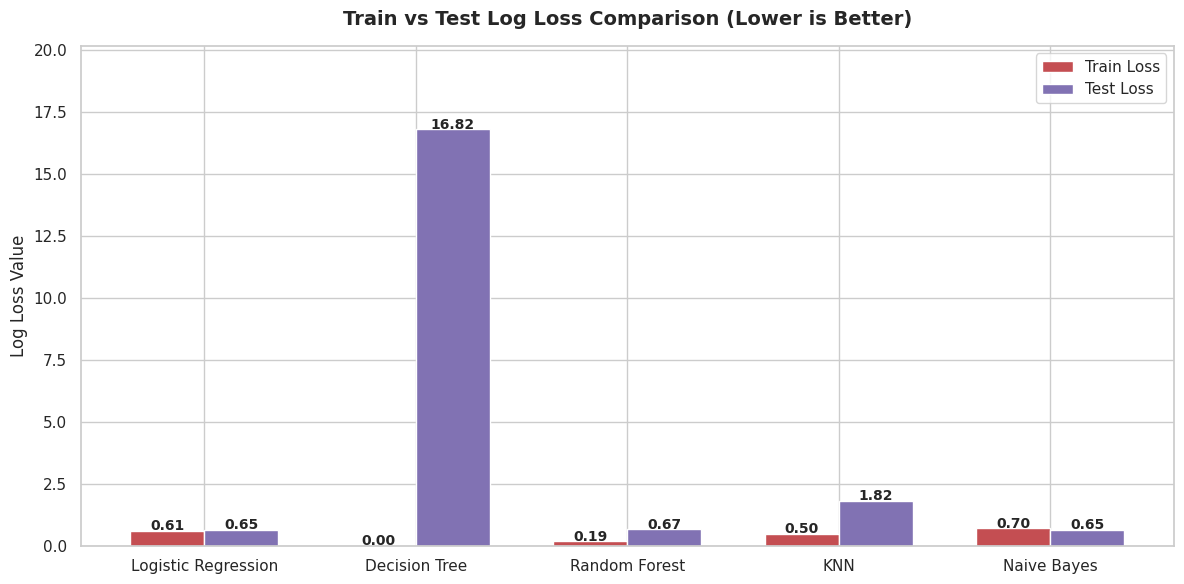

In [258]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss

# 1. Split Data (Using your exact 10 columns, Target: sex)
X = df.drop("sex", axis=1)
y = df["sex"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Initialize your exact 5 models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# 3. Train models and calculate Train/Test Loss using probabilities
train_losses = {}
test_losses = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # We use predict_proba() because Log Loss evaluates probability scores
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    
    train_losses[name] = log_loss(y_train, train_prob)
    test_losses[name] = log_loss(y_test, test_prob)

# 4. Setup Plotting Layout
sns.set_theme(style="whitegrid")
model_names = list(models.keys())
x_indexes = np.arange(len(model_names))
bar_width = 0.35
plt.figure(figsize=(12, 6))

# 5. Create Grouped Bar Chart
plt.bar(x_indexes - bar_width/2, list(train_losses.values()), width=bar_width, label='Train Loss', color='#C44E52')
plt.bar(x_indexes + bar_width/2, list(test_losses.values()), width=bar_width, label='Test Loss', color='#8172B3')

# 6. Add labels on top of each bar
for i in range(len(model_names)):
    plt.text(i - bar_width/2, list(train_losses.values())[i] + 0.02, f"{list(train_losses.values())[i]:.2f}", ha='center', fontsize=10, weight='bold')
    plt.text(i + bar_width/2, list(test_losses.values())[i] + 0.02, f"{list(test_losses.values())[i]:.2f}", ha='center', fontsize=10, weight='bold')

# 7. Chart Formatting
plt.title('Train vs Test Log Loss Comparison (Lower is Better)', fontsize=14, weight='bold', pad=15)
plt.xticks(x_indexes, model_names, fontsize=11)
plt.ylabel('Log Loss Value', fontsize=12)
plt.ylim(0, max(max(train_losses.values()), max(test_losses.values())) * 1.2)
plt.legend(frameon=True)

# 8. Show Graph
plt.tight_layout()
plt.show()


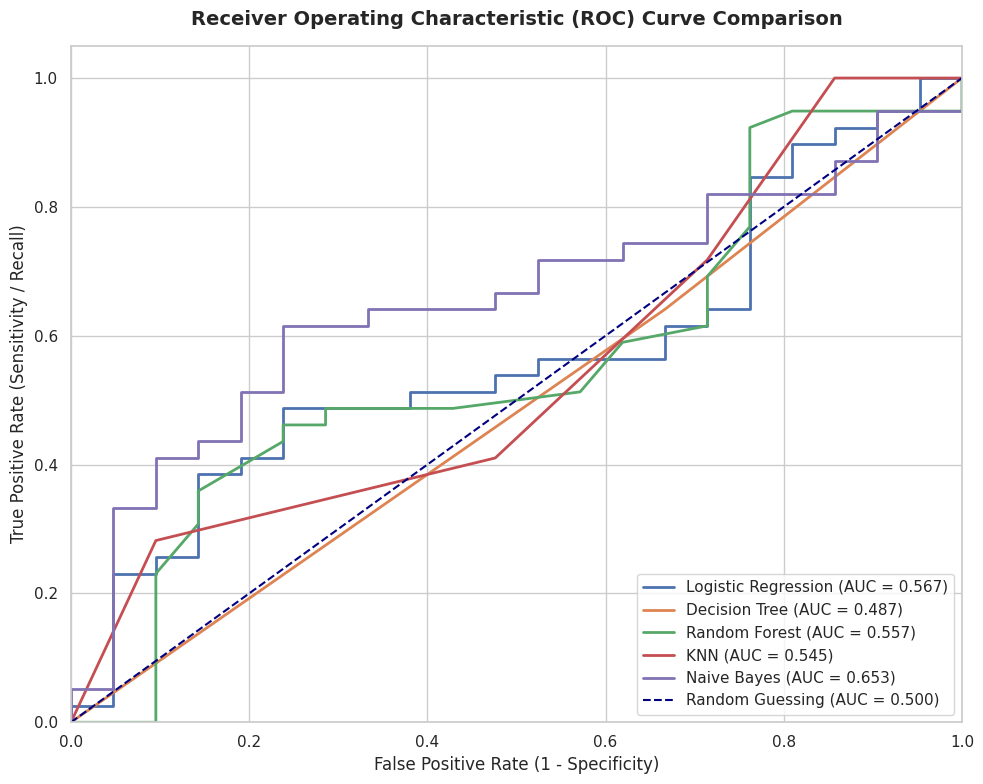

In [259]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc

# 1. Prepare Features (X) and Target (y)
X = df.drop("sex", axis=1)
y = df["sex"]

# 2. Split dataset into train and test sets (using stratification for clean evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Initialize your exact 5 models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# 4. Setup Plotting Layout
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# 5. Train each model, calculate probabilities, and plot its curve
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Get the predicted probabilities for the positive class (1)
    test_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate False Positive Rate (fpr) and True Variable Rate (tpr)
    fpr, tpr, _ = roc_curve(y_test, test_prob)
    roc_auc = auc(fpr, tpr)
    
    # Plot the line for the current model
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# 6. Plot the baseline diagonal line (representing random guessing)
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guessing (AUC = 0.500)')

# 7. Chart Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14, weight='bold', pad=15)
plt.legend(loc="lower right", frameon=True, fontsize=11)

# 8. Show Graph
plt.tight_layout()
plt.show()
